# High Fidelity Neural Network
Neural Network which uses HF dataset and exploits the High fidelity component of the MF model  

In [1]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions3D import (
    getModel,
    kCrossVal,
    transfBestparam,
    kCrossValSingle,
    import_data,
)
from time import perf_counter
import pandas
import os
from itertools import product
seed = 7
np.random.seed(seed)

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Data preparation

In [2]:
file_path_HF = os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_HF.mat")
(reaction_HF_test, U_HF_test, x_HF_test) = import_data(file_path_HF)



MemoryError: Unable to allocate 2.98 GiB for an array with shape (50, 801, 100, 100) and data type float64

In [ ]:
reaction_max = np.max(reaction_HF_test)
reaction_min = np.min(reaction_HF_test)
reaction_HF_test = (reaction_HF_test - reaction_min) / (
    reaction_max - reaction_min
)

In [ ]:
NepoHF = 5000  # number of epochs for second NN: NN_HF
Nhf = 15

In [ ]:
permutation1 = np.random.permutation(len(reaction_HF_test))
permutation2 = np.random.permutation(len(x_HF_test))

reaction_HF = reaction_HF_test[permutation1][0:Nhf]
x_HF = x_HF_test[permutation2][0:Nhf]
reaction_HF = np.column_stack((reaction_HF, x_HF))
#reaction_HF= np.array(list(product(reaction_HF.flatten(), x_HF.flatten())))
U_HF_test = U_HF_test[:, -1, :,44]


reaction_HF_test = np.array(list(product(reaction_HF_test.flatten(), x_HF_test.flatten())))

# TRANSFORMATION
U_h_max_test = np.max(U_HF_test)
U_h_min_test = np.min(U_HF_test)
#U_HF = (U_HF - U_h_min_test) / (U_h_max_test - U_h_min_test)
U_HF_test = (U_HF_test - U_h_min_test) / (U_h_max_test - U_h_min_test)

U_HF = U_HF_test[permutation1[0:Nhf],permutation2[0:Nhf]]
row, col = U_HF_test.shape
index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
U_HF_test = U_HF_test.flatten()[comb]



# Neural Network

In [ ]:
start = perf_counter()

reaction_final = np.vstack(
    (reaction_HF)
) 

MAX_EVAL = 2
name = "HF"  # I leave the same NN,  even if we use HF data instead of LF
K.clear_session()
bayes_trials = Trials()
opt_list = ["Adam", "Adamax"]
kernel_list = ["uniform", "glorot_uniform"]
aux_dic = {"opt": opt_list, "kernel_init": kernel_list}
space = {
    "nodes": hp.qloguniform("nodes", np.log(4), np.log(64), 2),
    "l2weight": hp.loguniform("l2weight", np.log(0.0001), np.log(100)),
    "lr": hp.loguniform("lr", np.log(0.0001), np.log(0.1)),
    "kernel_init": hp.choice("kernel_init", kernel_list),
    "opt": hp.choice("opt", opt_list),
}


def objective(params):
    K.clear_session()
    CVres = kCrossValSingle(Nhf, NepoHF, reaction_final, U_HF, params, name)
    return {"loss": CVres, "params": params, "status": STATUS_OK}


best_params = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=MAX_EVAL,
    trials=bayes_trials,
)

transfBestparam(best_params, aux_dic)
print(best_params)


  0%|          | 0/2 [00:00<?, ?trial/s, best loss=?]

1/1 [==============================] - 0s 68ms/step 

1/1 [==============================] - 0s 90ms/step 

1/1 [==============================] - 0s 67ms/step 

1/1 [==============================] - 0s 59ms/step 

1/1 [==============================] - 0s 67ms/step 

1/1 [==============================] - 0s 66ms/step 

1/1 [==============================] - 0s 67ms/step 

1/1 [==============================] - 0s 62ms/step 

1/1 [==============================] - 0s 65ms/step 

1/1 [==============================] - 0s 55ms/step 

1/1 [==============================] - 0s 74ms/step 

1/1 [==============================] - 0s 67ms/step 

1/1 [==============================] - 0s 67ms/step 

1/1 [==============================] - 0s 67ms/step 

1/1 [==============================] - 0s 63ms/step 

1/1 [==============================] - 0s 67ms/step                             

1/1 [==============================] - 0s 66ms/step                             

1/1 [=====================

In [ ]:
####################    NN training and PREDICTION    #######################
start2 = perf_counter()

finalModel = getModel(
    best_params, name
)  # final model chosen according to the best paramters
hist = finalModel.fit(
    reaction_HF,
    U_HF,
    validation_data=(reaction_HF_test, U_HF_test),
    epochs=NepoHF,
    batch_size=Nhf,
    verbose=0,
    validation_freq=20,
)

UHF = finalModel.predict(reaction_HF_test)

stop = perf_counter()
elapsed = stop - start
print("Elapsed time: ", elapsed)
print("\nHF Model:")

elapsed2 = stop - start2
print("Elapsed time: ", elapsed2)
print("\nHF Model:")
test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
print(f"Test MSE: {test_mse}")

r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
    np.square(U_HF_test - np.mean(U_HF_test))
)
print(f"R^2: {r2_HF}")

157/157 [==============================] - 0s 2ms/step
Elapsed time:  576.519561100009

HF Model:
Elapsed time:  87.31173349999881

HF Model:
Test MSE: 0.15274533685061023
R^2: -0.36787533797830485


# Post processing

157/157 [==============================] - 0s 2ms/step


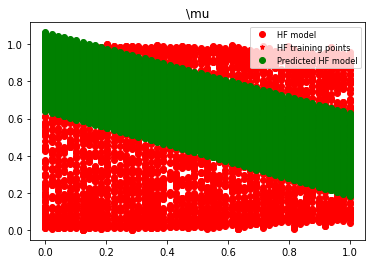

157/157 [==============================] - 1s 3ms/step


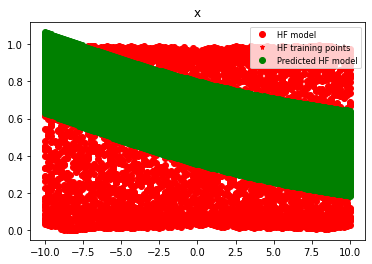

In [ ]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
mask1_test=np.where(reaction_HF_test[:,1]==np.min(reaction_HF_test[:,1]))
mask1=np.where(reaction_HF[:,1]==np.min(reaction_HF[:,1]))

# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
plt.plot(reaction_HF_test[mask1_test,0], U_HF_test, "ro", linewidth=1.5, label="HF model")
plt.plot(reaction_HF[mask1,0], U_HF, "r*", markersize=5, label="HF training points")
plt.plot(
    reaction_HF_test[mask1_test,0],
    finalModel.predict(reaction_HF_test),
    "go",
    linewidth=3,
    label="Predicted HF model",
)
plt.legend(prop={"size": 8.3})
plt.title("\mu")
plt.show()

mask2_test=np.where(reaction_HF_test[:,0]==np.min(reaction_HF_test[:,0]))
mask2=np.where(reaction_HF[:,0]==np.min(reaction_HF[:,0]))
plt.figure()
# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
plt.plot(reaction_HF_test[mask2_test,1], U_HF_test, "ro", linewidth=1.5, label="HF model")
plt.plot(reaction_HF[mask2,1], U_HF, "r*", markersize=5, label="HF training points")
plt.plot(
    reaction_HF_test[mask2_test,1],
    finalModel.predict(reaction_HF_test),
    "go",
    linewidth=3,
    label="Predicted HF model",
)
plt.legend(prop={"size": 8.3})
plt.title("x")
plt.show()

ValueError: cannot reshape array of size 5000 into shape (15,15)

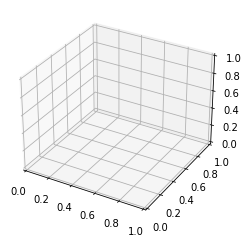

In [ ]:
#x, y = np.meshgrid(x, y)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plotta la superficie
U_HF_test = U_HF_test.reshape(reaction_HF[:, 0].size, reaction_HF[:, 1].size)
ax.plot_surface(reaction_HF[:,0], reaction_HF[:,1], U_HF_test, cmap='viridis')
ax.plot_surface(reaction_HF[:,0], reaction_HF[:,1], U_HF, label="HF training points")
plt.plot(reaction_HF[:,0], U_HF, "r*", markersize=5, label="HF training points")
ax.plot_surface(
    reaction_HF_test[:,0],reaction_HF_test[:,1],
    finalModel.predict(reaction_HF_test),
    "go",
    linewidth=3,
    label="Predicted HF model",
)
# Aggiungi una barra dei colori

# Mostra il plot
plt.show()

In [ ]:
########################     SAVE the OUTPUT      ##########################

# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! change the name of the new folder !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! 
os.makedirs("NNHF_HF_15")

R2_HF = pandas.DataFrame({"R2_HF": [r2_HF]})
MSE_test_HF = pandas.DataFrame({"MSE_test_HF": [test_mse]})


# R2_LF.to_csv('./Output_NNHF/r2_HF.txt', header=True, index=False, sep='\t', mode='a')
MSE_test_HF.to_csv(
    "./NNHF_HF_15/test_mse.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
R2_HF.to_csv(
    "./NNHF_HF_15/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

In [ ]:
permutation1 = np.random.permutation(len(reaction_LF_test))
permutation2 = np.random.permutation(len(x_LF_test))

reaction_LF = reaction_LF_test[permutation1][0:Nlf]
x_LF = x_LF_test[permutation2][0:Nlf]
#reaction_LF = np.column_stack((reaction_LF, x_LF))
reaction_LF= np.array(list(product(reaction_LF.flatten(), x_LF.flatten())))

U_LF_test = U_LF_test[:, -1, :,12]


reaction_LF_test = np.array(list(product(reaction_LF_test.flatten(), x_LF_test.flatten())))

# TRANSFORMATION
U_h_max_test = np.max(U_LF_test)
U_h_min_test = np.min(U_LF_test)
#U_HF = (U_HF - U_h_min_test) / (U_h_max_test - U_h_min_test)
U_LF_test = (U_LF_test - U_h_min_test) / (U_h_max_test - U_h_min_test)

U_LF = U_LF_test[permutation1[0:Nlf],permutation2[0:Nlf]]
row, col = U_LF_test.shape
index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
U_LF_test = U_LF_test.flatten()[comb]